# Demo 2 — PINN for the 1D viscous Burgers' equation

This is the canonical demo from Raissi, Perdikaris & Karniadakis (2019) — the paper that put "PINN" on the map. We're going to solve

$$ u_t + u\,u_x - \nu\,u_{xx} = 0, \qquad x \in [-1, 1],\ t \in [0, 1], $$

with initial condition $u(0, x) = -\sin(\pi x)$ and Dirichlet boundary conditions $u(t, \pm 1) = 0$. We use $\nu = 0.01/\pi$, which is small enough that the smooth sinusoidal initial condition develops a near-shock around $x=0$ by $t \approx 0.4$.

**What's different from Notebook 1:** the input is now a 2D point $(t, x)$ instead of a scalar $t$. The physics residual involves spatial derivatives. Otherwise the recipe is identical: MLP output, autodiff for derivatives, residual + boundary + initial losses on collocation points.

This is a **forward** problem — no measurements, just the equation and its boundary/initial data. The PINN replaces a traditional finite-difference / finite-element solver.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = "cpu"

MIT_RED = "#A31F34"
MIT_GRAY = "#8A8B8C"
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Problem constants
NU = 0.01 / np.pi
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX = 0.0, 1.0

## Sampling the three loss regions

A PINN for a PDE on a 2D domain needs three sample sets:

1. **Initial condition** — points along $t = 0$, where we know $u = -\sin(\pi x)$.
2. **Boundary condition** — points along $x = \pm 1$, where $u = 0$.
3. **Collocation interior** — random $(t, x)$ points inside the domain where the PDE residual should vanish.

Latin-hypercube or random uniform sampling both work. We'll just use uniform random — simpler, plenty for this problem.

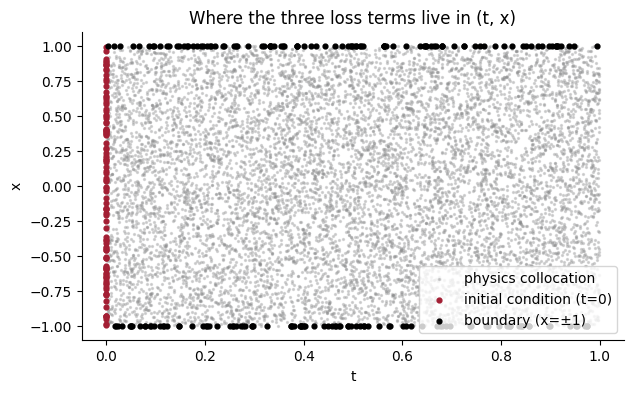

In [2]:
N_IC = 100      # points on t=0
N_BC = 100      # points on each spatial boundary
N_COLLOCATION = 10000  # interior physics points

# Initial condition: t=0, x ~ uniform[-1, 1], u = -sin(pi x)
x_ic = torch.rand(N_IC, 1, device=device) * (X_MAX - X_MIN) + X_MIN
t_ic = torch.zeros_like(x_ic)
u_ic = -torch.sin(np.pi * x_ic)

# Boundary conditions: x=+/-1, t ~ uniform[0, 1], u = 0
t_bc = torch.rand(2 * N_BC, 1, device=device) * (T_MAX - T_MIN) + T_MIN
x_bc = torch.cat([
    torch.full((N_BC, 1), X_MIN, device=device),
    torch.full((N_BC, 1), X_MAX, device=device),
])
u_bc = torch.zeros_like(t_bc)

def sample_collocation(n: int):
    '''Fresh (t, x) collocation points, as leaf tensors with requires_grad=True.

    We resample every training step. This (a) keeps the autograd graph fresh —
    if you reuse the same tensors across .backward() calls you'll see
    "trying to backward through the graph a second time" errors — and
    (b) acts like stochastic mini-batching over the physics-loss domain,
    which empirically helps PINN convergence.
    '''
    t = torch.empty(n, 1, device=device).uniform_(T_MIN, T_MAX).requires_grad_(True)
    x = torch.empty(n, 1, device=device).uniform_(X_MIN, X_MAX).requires_grad_(True)
    return t, x

# Visualize a sample
_t_show, _x_show = sample_collocation(N_COLLOCATION)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(_t_show.detach(), _x_show.detach(), s=2, color=MIT_GRAY, alpha=0.3, label="physics collocation")
ax.scatter(t_ic, x_ic, s=12, color=MIT_RED, label="initial condition (t=0)")
ax.scatter(t_bc, x_bc, s=12, color="black", label="boundary (x=±1)")
ax.set_xlabel("t"); ax.set_ylabel("x")
ax.set_title("Where the three loss terms live in (t, x)")
ax.legend(loc="lower right")
plt.show()

## The PINN

A 2-input MLP (`t, x → u`). The physics residual involves first time derivative, first and second spatial derivatives — all from autograd.

In [3]:
class PINN(nn.Module):
    def __init__(self, width=40, depth=8):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))


def grad(y, x):
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]


def physics_residual(model, t, x):
    '''Burgers' residual: u_t + u u_x - nu u_xx.'''
    u = model(t, x)
    u_t = grad(u, t)
    u_x = grad(u, x)
    u_xx = grad(u_x, x)
    return u_t + u * u_x - NU * u_xx


model = PINN().to(device)
print(f"trainable parameters: {sum(p.numel() for p in model.parameters())}")

trainable parameters: 11641


## Training

Adam for a few thousand steps. The Raissi paper uses L-BFGS as a polish — we'll skip that for clarity; Adam alone gets us a clean solution in well under a minute on CPU.

Weights matter: the initial-condition loss needs to be pulled up (here `w_ic=10`) so the network actually anchors at the sinusoidal start rather than minimizing the physics residual with a trivial solution.

In [4]:
N_STEPS = 5000
LR = 1e-3
W_PHYS, W_IC, W_BC = 1.0, 10.0, 10.0

opt = torch.optim.Adam(model.parameters(), lr=LR)
history = {"total": [], "phys": [], "ic": [], "bc": []}

for step in range(N_STEPS):
    opt.zero_grad()

    t_co, x_co = sample_collocation(N_COLLOCATION)
    r = physics_residual(model, t_co, x_co)
    loss_phys = (r ** 2).mean()

    u_pred_ic = model(t_ic, x_ic)
    loss_ic = ((u_pred_ic - u_ic) ** 2).mean()

    u_pred_bc = model(t_bc, x_bc)
    loss_bc = ((u_pred_bc - u_bc) ** 2).mean()

    loss = W_PHYS * loss_phys + W_IC * loss_ic + W_BC * loss_bc
    loss.backward()
    opt.step()

    history["total"].append(loss.item())
    history["phys"].append(loss_phys.item())
    history["ic"].append(loss_ic.item())
    history["bc"].append(loss_bc.item())

    if (step + 1) % 1000 == 0:
        print(f"step {step+1:5d}  total={loss.item():.4e}  "
              f"phys={loss_phys.item():.4e}  ic={loss_ic.item():.4e}  bc={loss_bc.item():.4e}")

step  1000  total=2.6605e-01  phys=2.2210e-01  ic=4.1140e-03  bc=2.8065e-04


step  2000  total=2.0759e-01  phys=1.6900e-01  ic=3.6637e-03  bc=1.9512e-04


step  3000  total=9.8343e-02  phys=8.4524e-02  ic=1.3072e-03  bc=7.4697e-05


step  4000  total=1.8300e-02  phys=1.5801e-02  ic=2.0185e-04  bc=4.8067e-05


step  5000  total=6.9562e-03  phys=4.9412e-03  ic=1.5906e-04  bc=4.2440e-05


## Visualize the learned solution

We sample the trained network on a regular (t, x) grid and plot:

1. A heatmap of $u(t, x)$ over the full domain.
2. Snapshots of $u(t, \cdot)$ at a few times so you can see the sinusoid steepening into a near-shock around $x = 0$.

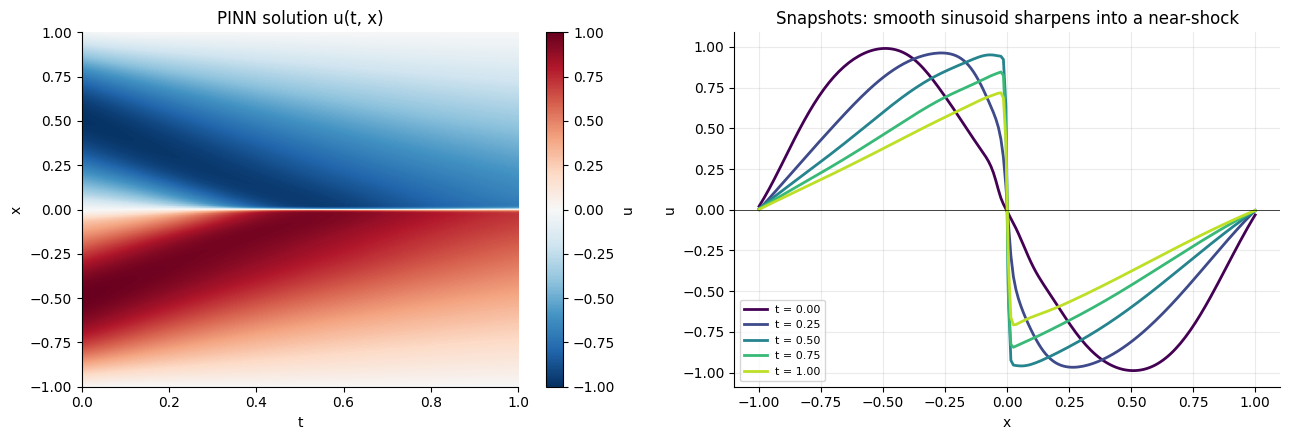

In [5]:
N = 200
t_plot = torch.linspace(T_MIN, T_MAX, N, device=device)
x_plot = torch.linspace(X_MIN, X_MAX, N, device=device)
T_grid, X_grid = torch.meshgrid(t_plot, x_plot, indexing="ij")
with torch.no_grad():
    U = model(T_grid.reshape(-1, 1), X_grid.reshape(-1, 1)).reshape(N, N).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im = axes[0].imshow(
    U.T,
    origin="lower",
    extent=[T_MIN, T_MAX, X_MIN, X_MAX],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
)
axes[0].set_xlabel("t"); axes[0].set_ylabel("x")
axes[0].set_title("PINN solution u(t, x)")
plt.colorbar(im, ax=axes[0], label="u")

snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(snapshot_times)))
for c, ts in zip(colors, snapshot_times):
    with torch.no_grad():
        t_s = torch.full((N, 1), ts, device=device)
        x_s = x_plot.view(-1, 1)
        u_s = model(t_s, x_s).cpu().numpy().ravel()
    axes[1].plot(x_plot.cpu().numpy(), u_s, color=c, lw=2, label=f"t = {ts:.2f}")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_xlabel("x"); axes[1].set_ylabel("u")
axes[1].set_title("Snapshots: smooth sinusoid sharpens into a near-shock")
axes[1].legend(loc="lower left", fontsize=8)
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

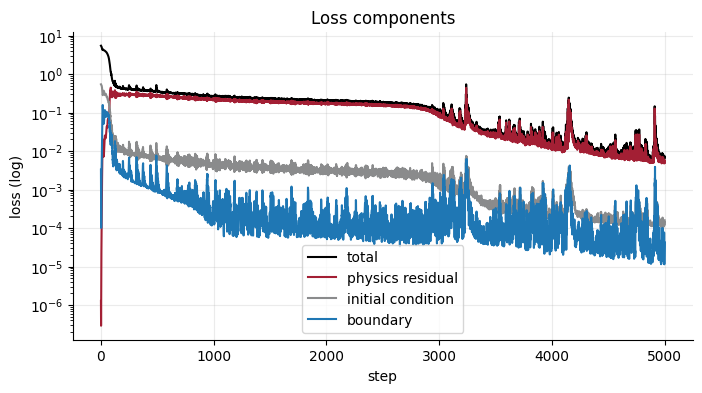

In [6]:
# Loss history
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history["total"], color="black", label="total")
ax.semilogy(history["phys"], color=MIT_RED, label="physics residual")
ax.semilogy(history["ic"], color=MIT_GRAY, label="initial condition")
ax.semilogy(history["bc"], color="tab:blue", label="boundary")
ax.set_xlabel("step"); ax.set_ylabel("loss (log)")
ax.set_title("Loss components")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Things to play with

- **`NU`** at top: try `0.1/np.pi` (smoother) and `0.001/np.pi` (sharper shock that the PINN may struggle to resolve without more collocation points or a wider network).
- **`N_COLLOCATION`**: drop to 500. The shock region gets noisy — the PINN doesn't have enough physics samples to constrain the gradient there.
- **`W_IC` / `W_BC`**: set to 1.0 (no upweighting). The network often collapses to the trivial $u \equiv 0$ because the IC term gets dominated by the physics residual.
- **Width / depth** in `PINN.__init__`: shrink to width=16, depth=3. Watch the solution get visibly worse. Grow to width=80, depth=10 and see if you can tighten the shock.
- **Replace Adam with L-BFGS** for the last 1000 steps. Raissi's paper does this; it gives a sharper shock at the cost of more code.
- **Add data.** Sample 20 points from a finite-difference reference, add a `loss_data` term, and watch the PINN tighten where it agrees with the reference.

## What this notebook is *not*

This is a forward solve — we used the PINN as a mesh-free PDE solver. Modern numerical methods will still beat a PINN at this problem on accuracy and wall-clock time. The PINN really shines on:

- **Inverse problems** (identify unknown coefficients from data — Notebook 1 covered this for an ODE).
- **High-dimensional PDEs** where meshing is prohibitive.
- **Embedding partial physics into a data-driven model** when only part of the equation is known.

The third one is where [my paper](../main.pdf) lives — and the next slide picks it up.